# Prequential Evaluation capyMOA

In [ ]:
from capymoa.anomaly import OnlineIsolationForest
from capymoa.anomaly import HalfSpaceTrees
from capymoa.evaluation.visualization import plot_windowed_results
from capymoa.evaluation import prequential_evaluation_anomaly
from src.Data.Processor import DataStreamProcessor
import pandas as pd

df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

processor = DataStreamProcessor(logging=True)

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

oif = OnlineIsolationForest(schema=stream.get_schema())
hst = HalfSpaceTrees(schema=stream.get_schema())

results_hst = prequential_evaluation_anomaly(
    stream=stream, learner=hst, window_size=200
)

results_oif = prequential_evaluation_anomaly(
    stream=stream, learner=oif, window_size=200
)

In [ ]:
# print("Half-Space Trees Results:")
# print(f"AUC: {results_hst.auc()}")
# print(f"Accuracy: {results_hst.accuracy()}")
# print(f"Recall: {results_hst.recall()}")

# print("Online Isolation Forest Results:")
# print(f"AUC: {results_oif.auc()}")
# print(f"Accuracy: {results_oif.accuracy()}")
# print(f"Recall: {results_oif.recall()}")

display(results_hst.windowed.metrics_per_window())
plot_windowed_results(results_hst, results_oif, metric="Accuracy", save_only=False)
plot_windowed_results(results_hst, results_oif, metric="Recall", save_only=False)
plot_windowed_results(results_hst, results_oif, metric="auc", save_only=False)

# Execução Pipelines

https://www.researchgate.net/publication/318919520_Anomaly_Detection_in_Streams_with_Extreme_Value_Theory

## Otimização Optuna

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.Data.Processor import DataStreamProcessor

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '250', '500', '1000', '2000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

# Dicionário/Counter para armazenar a contagem global das features
contagem_features = Counter()

print("Iniciando extração e contagem de features...")

for dataset_path in datasets:
    print(f"-> Analisando: {dataset_path}")
    
    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"   [!] Arquivo não encontrado. Pulando...")
        continue
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=25,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )
    
    # Adiciona as 25 features deste cenário ao nosso contador global
    contagem_features.update(features)


# Pega as 25 features que mais apareceram somando todos os cenários
top_25_globais = contagem_features.most_common(25)

# Separa em duas listas para facilitar o gráfico
nomes_features = [f[0] for f in top_25_globais]

print("\n" + "="*70)
print(" ARRAY COM AS MELHORES FEATURES ".center(70))
print("="*70)
print("melhores_features = [")
for feat in nomes_features:
    print(f"    '{feat}',")
print("]")

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Optimizer import AnomalyOptunaOptimizer
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '250', '500', '1000', '2000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Min Packet Length',
    'act_data_pkt_fwd',
    'Subflow Fwd Bytes',
    'Fwd Packet Length Min',
    'Total Length of Fwd Packets',
    'Packet Length Mean',
    'Average Packet Size',
    'Total Fwd Packets',
    'Avg Fwd Segment Size',
    'Fwd Packets/s',
    'Fwd Packet Length Mean',
    'Max Packet Length',
    'Init_Win_bytes_forward',
    'Fwd Packet Length Max',
    'Inbound',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'Flow IAT Mean',
    'URG Flag Count',
    'Fwd IAT Mean',
    'Flow IAT Max',
    'Total Backward Packets',
    'Init_Win_bytes_backward',
    'Flow IAT Std',
    'ACK Flag Count',
]

for dataset_path in datasets:
    print(f"\nIniciando otimização para: {dataset_path}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )
    
    optimizer = AnomalyOptunaOptimizer(
        stream=stream,
        n_trials=200,
        discretization_threshold='params',
        target_class=None,
        target_names=targets
    )

    melhor_hst = optimizer.optimize('HST')
    # melhor_oif = optimizer.optimize('OIF')
    # melhor_aif = optimizer.optimize('AIF')
    # melhor_aif = optimizer.optimize('AE', warmup_instances=0)
    # melhor_rrcf = optimizer.optimize('RRCF')

## Resultados

### Consistência

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=True)

# df = pd.read_csv('data/15k/Consistência/Consistência_25.csv')
df = pd.read_csv('data/15k/Consistência/Consistência_250.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_500.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_1000.csv')
# df = pd.read_csv('data/15k/Warm-up/Warm-up_3.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=None,
    threshold_corr=None,
    top_n_features=25,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Configurar seus algoritmos 
algoritmos = get_anomaly_models(
    stream.get_schema(), 
    selected_models=['AE']
)

# Instancia o objeto do experimento
runner = AnomalyExperimentRunner(target_names=targets)

runner._run_anomaly_ae(
    stream, 
    algorithms=algoritmos,
    window_size=2048,
    warmup_instances=1000,
    title="Consistência",
    target_class=None,
    threshold=0.65
)

### Generalização

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)

# df = pd.read_csv('data/15k/Generalização/Generalização_25.csv')
# df = pd.read_csv('data/15k/Generalização/Generalização_250.csv')
df = pd.read_csv('data/15k/Generalização/Generalização_500.csv')
# df = pd.read_csv('data/15k/Generalização/Generalização_1000.csv')
# df = pd.read_csv('data/15k/Generalização/Generalização_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Configurar seus algoritmos 
algoritmos = get_anomaly_models(
    stream.get_schema(), 
    selected_models=['AE'],
    ae_params={'hidden_layer': 17, 'learning_rate': 0.00313, 'threshold': 0.70}
)

# Instancia o objeto do experimento
runner = AnomalyExperimentRunner(target_names=targets)

runner._run_anomaly_evaluation(
    stream, 
    algorithms=algoritmos,
    window_size=2048,
    warmup_instances=0,
    title="Generalização",
    target_class=None,
    threshold=0.85
)

### Adaptação

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia para criar o stream
processor = DataStreamProcessor(logging=False)

# df = pd.read_csv('data/15k/Adaptação/Adaptação_25.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_250.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_500.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_1000.csv')
df = pd.read_csv('data/15k/Adaptação/Adaptação_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Configurar seus algoritmos 
algoritmos = get_anomaly_models(
    stream.get_schema(), 
    selected_models=['HST'],
    hst_params={'window_size': 1850, 'max_depth': 8, 'anomaly_threshold': 0.30, 'size_limit': 0.50}
)

# Instancia o objeto do experimento
runner = AnomalyExperimentRunner(target_names=targets)

runner._run_anomaly_evaluation(
    stream, 
    algorithms=algoritmos,
    window_size=2048,
    warmup_instances=0,
    title="Adaptação",
    target_class=None,
    threshold=0.40
)

### Recorrência

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)

# df = pd.read_csv('data/15k/Recorrência/Recorrência_25.csv')
# df = pd.read_csv('data/15k/Recorrência/Recorrência_250.csv')
# df = pd.read_csv('data/15k/Recorrência/Recorrência_500.csv')
# df = pd.read_csv('data/15k/Recorrência/Recorrência_1000.csv')
df = pd.read_csv('data/15k/Recorrência/Recorrência_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=False, 
    normalize_method="MinMaxScaler", 
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

runner = AnomalyExperimentRunner(target_names=targets)

# Configurar seus algoritmos 
algoritmos = get_anomaly_models(
    stream.get_schema(), 
    selected_models=['HST'],
    hst_params={'window_size': 2000, 'max_depth': 19, 'anomaly_threshold': 0.20, 'size_limit': 0.25}
)

runner._run_anomaly_evaluation(
    stream, 
    algorithms=algoritmos,
    window_size=2048,
    warmup_instances=0,
    title="Recorrência",
    target_class=None,
    threshold=0.45
)

## Loop Treino

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '250', '500', '1000', '2000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Min Packet Length',
    'act_data_pkt_fwd',
    'Subflow Fwd Bytes',
    'Fwd Packet Length Min',
    'Total Length of Fwd Packets',
    'Packet Length Mean',
    'Average Packet Size',
    'Total Fwd Packets',
    'Avg Fwd Segment Size',
    'Fwd Packets/s',
    'Fwd Packet Length Mean',
    'Max Packet Length',
    'Init_Win_bytes_forward',
    'Fwd Packet Length Max',
    'Inbound',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'Flow IAT Mean',
    'URG Flag Count',
    'Fwd IAT Mean',
    'Flow IAT Max',
    'Total Backward Packets',
    'Init_Win_bytes_backward',
    'Flow IAT Std',
    'ACK Flag Count',
]

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AE']
    )
    
    runner = AnomalyExperimentRunner(target_names=targets)
    
    runner._run_anomaly_ae(
        stream,
        algorithms=algoritmos,
        window_size=2048,
        warmup_instances=1000,
        title=nome_experimento,
        target_class=None,
        threshold=0.834
    )

# Discretização DSPOT

## Otimização

In [ ]:
%load_ext autoreload
%autoreload 2

import optuna
import pandas as pd
import time
from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
optuna.logging.set_verbosity(optuna.logging.WARNING)

categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '250', '500', '1000', '2000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Min Packet Length',
    'act_data_pkt_fwd',
    'Subflow Fwd Bytes',
    'Fwd Packet Length Min',
    'Total Length of Fwd Packets',
    'Packet Length Mean',
    'Average Packet Size',
    'Total Fwd Packets',
    'Avg Fwd Segment Size',
    'Fwd Packets/s',
    'Fwd Packet Length Mean',
    'Max Packet Length',
    'Init_Win_bytes_forward',
    'Fwd Packet Length Max',
    'Inbound',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'Flow IAT Mean',
    'URG Flag Count',
    'Fwd IAT Mean',
    'Flow IAT Max',
    'Total Backward Packets',
    'Init_Win_bytes_backward',
    'Flow IAT Std',
    'ACK Flag Count',
]

processor = DataStreamProcessor(logging=False, selected_features=features)

algoritmos_para_testar = ['AIF']

def objective(trial, dataset_path, alg_name):
    dspot_q = trial.suggest_float('q', 1e-6, 1e-1, log=True)
    dspot_depth = trial.suggest_int('depth', 100, 400)
    dspot_t = trial.suggest_float('t_quantile', 0.93, 0.99)

    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        raise optuna.exceptions.TrialPruned()

    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )

    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=[alg_name]
    )

    runner = AnomalyExperimentRunner(target_names=targets)
    titulo_dinamico = f"Trial {trial.number} | {alg_name} | q: {dspot_q:.5f} | d: {dspot_depth} | t: {dspot_t:.3f}"
    
    resultados = runner._run_anomaly_DSPOT(
        stream=stream,
        algorithms=algoritmos,
        window_size=2048,
        warmup_instances=1000,
        title=titulo_dinamico,
        target_class=None,
        dspot_q=dspot_q,
        dspot_depth=dspot_depth,
        dspot_t_quantile=dspot_t 
    )
    

    f1_val = resultados.get('f1_score', 0.0)
    prec_val = resultados.get('precision', 0.0)
    rec_val = resultados.get('recall', 0.0)

    # SALVANDO MÉTRICAS EXTRAS NO OPTUNA
    trial.set_user_attr('precision', prec_val)
    trial.set_user_attr('recall', rec_val)

    print(f"[{alg_name}] Trial {trial.number:03d}")
    print(f"   -> Params  | q: {dspot_q:.6f} | depth: {dspot_depth} | t_quantile: {dspot_t:.4f}")
    print(f"   -> Métricas| F1: {f1_val:.2f}% | Prec: {prec_val:.2f}% | Rec: {rec_val:.2f}%\n")

    return f1_val

melhores_parametros_geral = {}

for alg in algoritmos_para_testar:
    print(f"\n{'='*70}")
    print(f" INICIANDO OTIMIZAÇÃO: ALGORITMO {alg} ")
    print(f"{'='*70}")
    melhores_parametros_geral[alg] = {}
    
    for dataset_path in datasets:
        print(f"\n--- Processando Dataset: {dataset_path.split('/')[-1]} ---\n")
        
        study_name = f"{alg}_{dataset_path.replace('/', '_')}"
        study = optuna.create_study(direction='maximize', study_name=study_name)
        
        study.optimize(lambda trial: objective(trial, dataset_path, alg), n_trials=50) 
        
        best_trial = study.best_trial
        
        melhores_parametros_geral[alg][dataset_path] = {
            'F1-Score': best_trial.value,
            'Precision': best_trial.user_attrs.get('precision', 0.0),
            'Recall': best_trial.user_attrs.get('recall', 0.0),
            'Tempo Execução (s)': best_trial.user_attrs.get('exec_time', 0.0),
            'q': best_trial.params['q'],
            'depth': best_trial.params['depth'],
            't_quantile': best_trial.params['t_quantile'],
            'Trial_Vencedor': best_trial.number
        }

print("\n\n" + "#"*70)
print(" RELATÓRIO FINAL DA OTIMIZAÇÃO DSPOT ".center(70, "#"))
print("#"*70)

for alg, datasets_results in melhores_parametros_geral.items():
    print(f"\n>> Algoritmo: {alg}")
    print("-" * 40)
    for ds, metrics in datasets_results.items():
        print(f"Dataset: {ds.split('/')[-1]} (Melhor Trial: {metrics['Trial_Vencedor']:03d})")
        print(f"  Métricas  -> F1-Score: {metrics['F1-Score']:.2f}% | Precision: {metrics['Precision']:.2f}% | Recall: {metrics['Recall']:.2f}%")
        print(f"  Parâmetros-> q: {metrics['q']:.6f} | depth: {metrics['depth']} | t_quantile: {metrics['t_quantile']:.4f}")
        print(f"  Tempo     -> {metrics['Tempo Execução (s)']:.2f} segundos")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

 INICIANDO OTIMIZAÇÃO: ALGORITMO AIF 

--- Processando Dataset: Consistência_25.csv ---

[AIF] Trial 000
   -> Params  | q: 0.056418 | depth: 312 | t_quantile: 0.9689
   -> Métricas| F1: 0.92% | Prec: 50.26% | Rec: 50.21%

[AIF] Trial 001
   -> Params  | q: 0.000107 | depth: 398 | t_quantile: 0.9626
   -> Métricas| F1: 77.20% | Prec: 68.98% | Rec: 98.89%

[AIF] Trial 002
   -> Params  | q: 0.004479 | depth: 289 | t_quantile: 0.9621
   -> Métricas| F1: 55.31% | Prec: 53.73% | Rec: 96.16%

[AIF] Trial 003
   -> Params  | q: 0.013655 | depth: 132 | t_quantile: 0.9777
   -> Métricas| F1: 50.39% | Prec: 51.95% | Rec: 93.68%

[AIF] Trial 004
   -> Params  | q: 0.003288 | depth: 282 | t_quantile: 0.9386
   -> Métricas| F1: 55.55% | Prec: 53.83% | Rec: 96.26%

[AIF] Trial 005
   -> Params  | q: 0.000060 | depth: 160 | t_quantile: 0.9726
   -> Métricas| F1: 71.94% | Prec: 64.37% | Rec: 98.68%

[AIF] Trial 0

## Treino DSPOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando treinamento para: Consistência_25

                                          RELATÓRIO ACUMULATIVO                                          
Algoritmo              | F1 (%)   | Prec (%) | Rec (%)  | TPR (%)  | FPR (%)  | MCC      | Tempo (s) 
---------------------------------------------------------------------------------------------------------
HalfSpaceTrees         | 50.99    | 53.06    | 50.64    | 1.39     | 0.107    | 0.028    | 14.67     



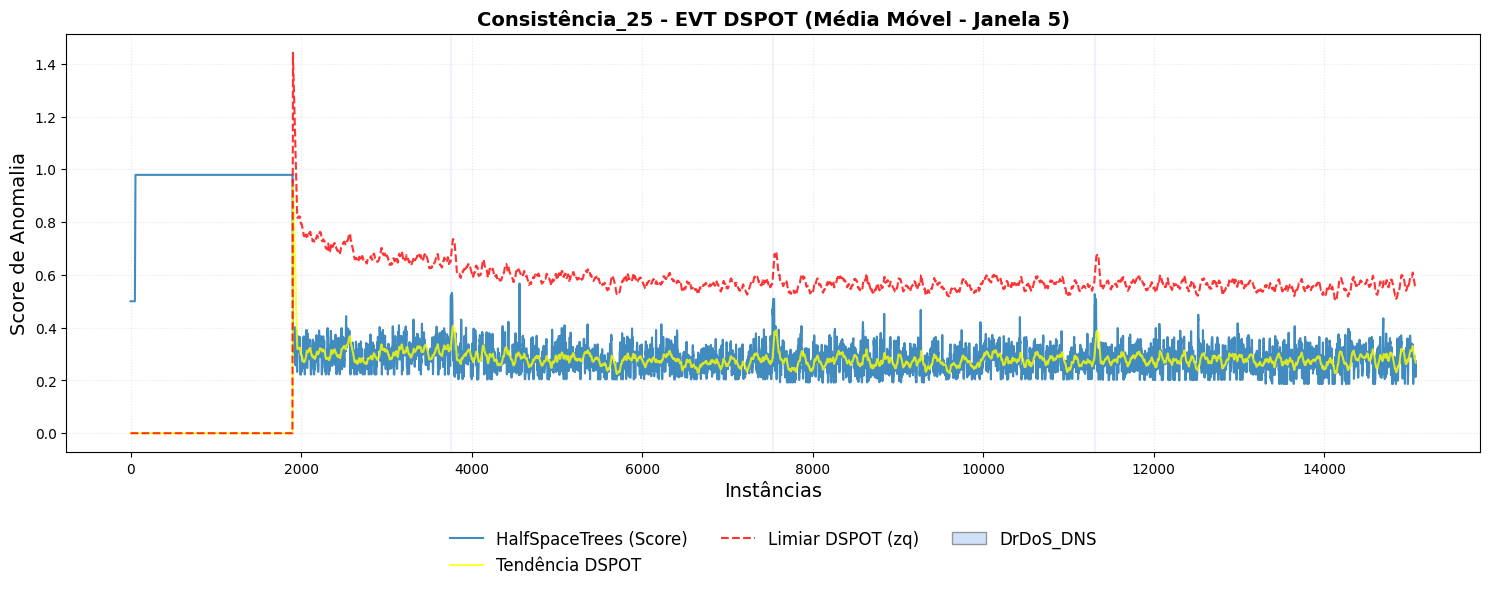

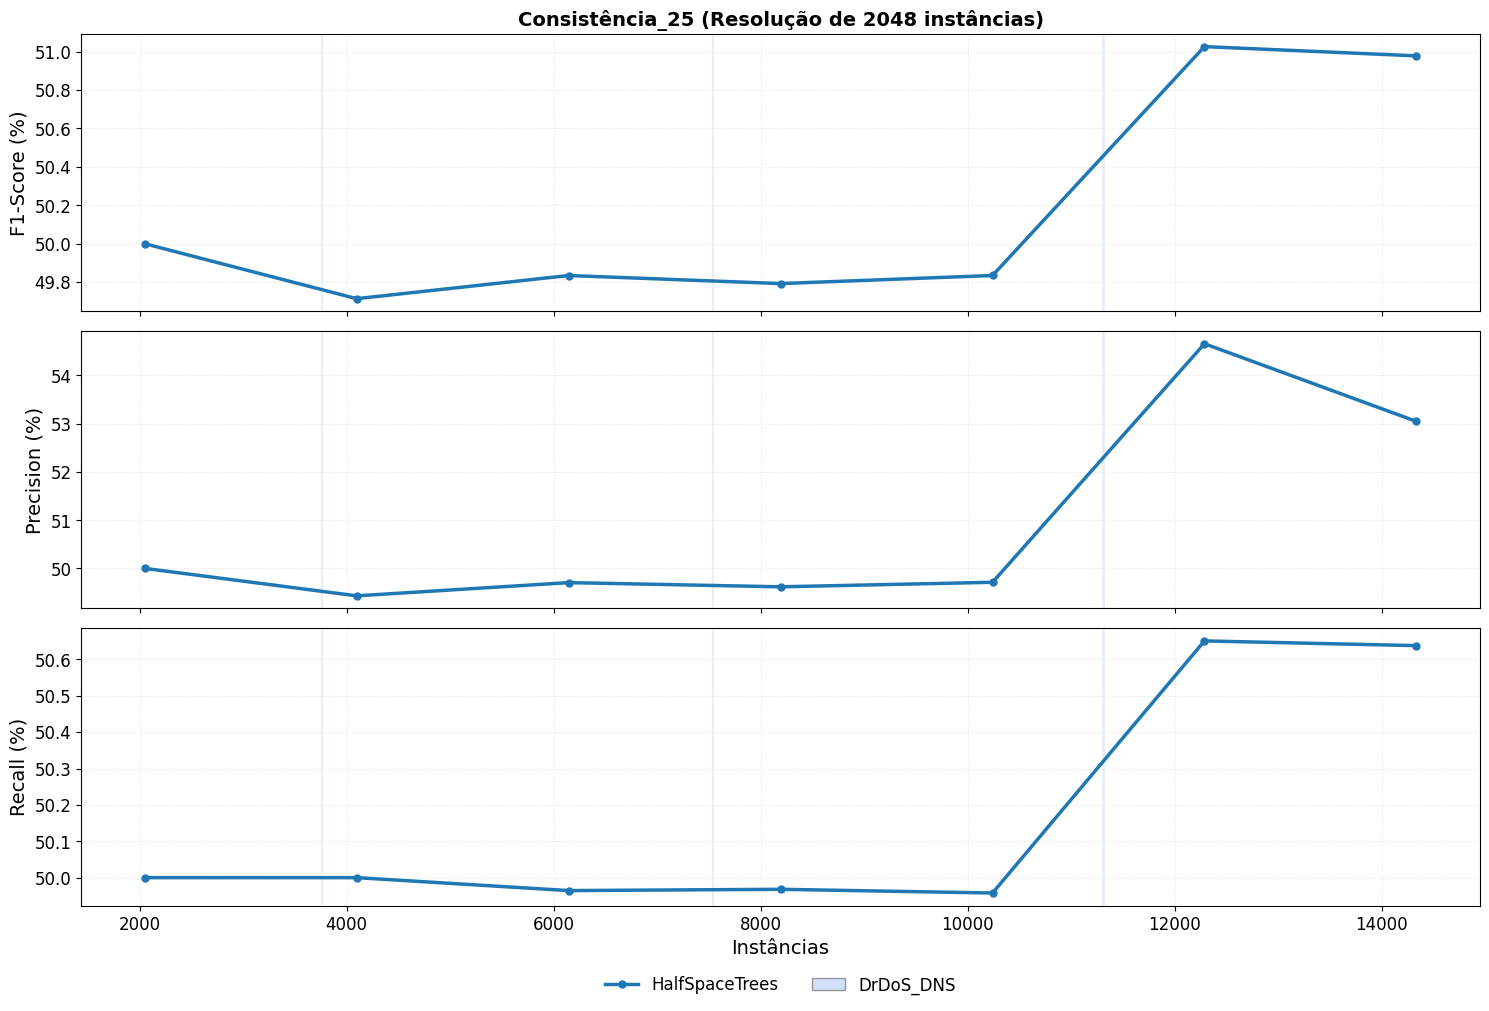


Iniciando treinamento para: Consistência_250


KeyboardInterrupt: 

In [125]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '250', '500', '1000', '2000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Min Packet Length',
    'act_data_pkt_fwd',
    'Subflow Fwd Bytes',
    'Fwd Packet Length Min',
    'Total Length of Fwd Packets',
    'Packet Length Mean',
    'Average Packet Size',
    'Total Fwd Packets',
    'Avg Fwd Segment Size',
    'Fwd Packets/s',
    'Fwd Packet Length Mean',
    'Max Packet Length',
    'Init_Win_bytes_forward',
    'Fwd Packet Length Max',
    'Inbound',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'Flow IAT Mean',
    'URG Flag Count',
    'Fwd IAT Mean',
    'Flow IAT Max',
    'Total Backward Packets',
    'Init_Win_bytes_backward',
    'Flow IAT Std',
    'ACK Flag Count',
]

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['HST']
    )
    
    runner = AnomalyExperimentRunner(target_names=targets)
    
    runner._run_anomaly_DSPOT(
        stream,
        algorithms=algoritmos,
        window_size=2048,
        warmup_instances=1900,
        title=nome_experimento,
        target_class=None,
        dspot_q=0.0025, 
        dspot_depth=51
    )

# Comparação

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor

categoria = 'Recorrência'
tamanhos = ['25', '250', '500', '1000', '2000']
processor = DataStreamProcessor(logging=False)

def criar_cenarios(categoria):
    scenarios = {}
    targets_globais = None
    
    for tam in tamanhos:
        dataset_path = f'data/15k/{categoria}/{categoria}_{tam}.csv'
        
        try:
            df = pd.read_csv(dataset_path)
        except FileNotFoundError:
            continue
            
        stream, targets, _ = processor.create_stream(
            df=df, 
            target_label_col='Label', 
            binary_label=False, 
            normalize_method="MinMaxScaler", 
            return_stream=True,
            extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'], 
            imputation_method='mediana'
        )
        targets_globais = targets
        
        algoritmos = get_anomaly_models(
            stream.get_schema(), 
            selected_models=['AIF']
        )
        nome_algoritmo = list(algoritmos.keys())[0]
        
        scenarios[tam] = {'stream': stream, 'learner': algoritmos[nome_algoritmo]}
        
    return scenarios, targets_globais

# Avaliação do Threshold Fixo
scenarios_fixo, targets_globais = criar_cenarios(categoria)
runner = AnomalyExperimentRunner(target_names=targets_globais)

resultados_fixo = runner._run_poisoning_evolution(
    scenarios_dict=scenarios_fixo, 
    threshold_type='fixed', 
    fixed_threshold=0.6
)

# Avaliação do DSPOT
scenarios_dspot, _ = criar_cenarios(categoria)

resultados_dspot = runner._run_poisoning_evolution(
    scenarios_dict=scenarios_dspot, 
    threshold_type='dspot', 
    warmup_instances=1000, 
    dspot_q=0.004, 
    dspot_depth=748
)

# Plotagem Lado a Lado
runner.plots.plot_poisoning_evolution(
    results_fixed=resultados_fixo,
    results_dspot=resultados_dspot,
    title=f'{categoria} - Adaptative Isolation Forest',
    fixed_threshold=0.6,
    window_size=5
)